What is the most optimal skill to learn for Data Analyst

Methodology

1.Group skills to determine median salary and likelihood of being in posting

2.Visualize median salary vs percent skill demand

3.(optimal) Determine if certain technologies are more prevalent

In [2]:
# Importing Library
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/python_course/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [4]:
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_US_exploded[['salary_year_avg', 'job_skills']].head(5)


,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [6]:
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_DA_US)

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


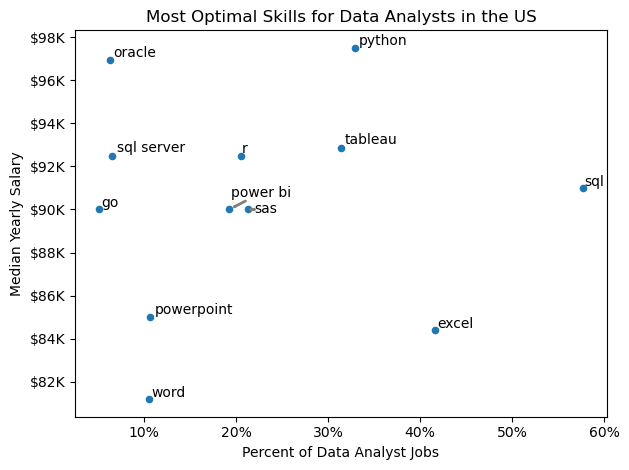

In [11]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap    
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=2))

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K') )
# Set Axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [12]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row) # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing
            technology_dict[key] += value
        else:
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['spss',
  'spreadsheet',
  'cognos',
  'qlik',
  'power bi',
  'sas',
  'datarobot',
  'alteryx',
  'ssrs',
  'tableau',
  'visio',
  'sharepoint',
  'powerbi',
  'sap',
  'splunk',
  'ms access',
  'dax',
  'looker',
  'word',
  'sheets',
  'outlook',
  'msaccess',
  'powerpoint',
  'esquisse',
  'nuix',
  'ssis',
  'excel',
  'microstrategy'],
 'programming': ['ocaml',
  'go',
  'visual basic',
  'c#',
  'c',
  'ruby',
  'cobol',
  'lisp',
  'dart',
  'elixir',
  'sql',
  'golang',
  'no-sql',
  'julia',
  'objective-c',
  'typescript',
  'rust',
  'javascript',
  'shell',
  'scala',
  'kotlin',
  'assembly',
  'haskell',
  'sas',
  'powershell',
  'mongo',
  'sass',
  'c++',
  'php',
  'delphi',
  'visualbasic',
  'python',
  't-sql',
  'swift',
  'java',
  'apl',
  'lua',
  'crystal',
  'perl',
  'erlang',
  'fortran',
  'vba',
  'css',
  'pascal',
  'bash',
  'solidity',
  'r',
  'matlab',
  'f#',
  'groovy',
  'nosql',
  'html',
  'clojure',
  'mongodb',
  'vb.

In [15]:
# Converting dictonary into Data Frame

df_technology = pd.DataFrame(list(technology_dict.items()) , columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,spss
0,analyst_tools,spreadsheet
0,analyst_tools,cognos
0,analyst_tools,qlik
0,analyst_tools,power bi
...,...,...
9,sync,symphony
9,sync,ringcentral
9,sync,zoom
9,sync,microsoft teams


In [18]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

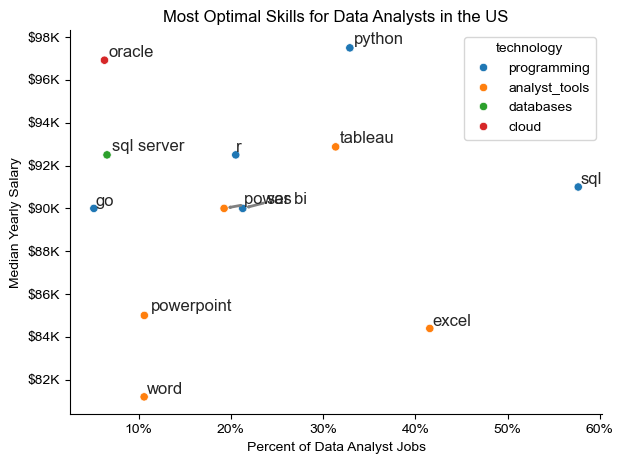

In [21]:
from adjustText import adjust_text

# df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')
sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')
# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap    
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=2))

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K') )
# Set Axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()